# 02 · Model training

**Automated Robson Ten-Group Classification and Cesarean Readiness System: ML workstream**

The model estimates **P(cesarean | data available at admission, under current practice)** as an
*operational readiness signal* (e.g. expected theatre load). It does **not** estimate clinical necessity,
and no output here is a recommendation for or against a cesarean section.

| # | Section | # | Section |
|---|---|---|---|
| 1 | Features and preprocessing | 6 | Experiment tracking (MLflow) |
| 2 | Model architectures | 7 | Performance metrics per model |
| 3 | Evaluation design | 8 | Confusion matrix per model |
| 4 | Training | 9 | Calibration and clinical utility |
| 5 | Hyperparameter tuning | 10 | Model selection |

**Model labels.** A configuration is `model|feature set|missing-data strategy|split|population`, e.g.
`logreg_l2|FS2|M2|S1|P_pred`: L2 logistic regression on feature set FS2, iterative imputation (M2),
evaluated leave-one-hospital-out (S1), on the prediction population.

Aggregates only, as in notebook 01. Results are read from the saved MLflow runs; out-of-fold predictions
are read only to compute aggregate metrics and curves.

In [1]:
from robson_ml import notebook

nb = notebook.setup()  # synthetic data unless ROBSON_NOTEBOOK_MODE=real
show = notebook.show

data: real


In [2]:
import tempfile
import time
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
from IPython.display import Markdown, display

from robson_ml import figures, tracking
from robson_ml.eda import calibration_bins, suppress_partition
from robson_ml.evaluate import ExperimentConfig, fold_tuning_study, make_folds, metric_key, run_experiment
from robson_ml.feature_sets import BASE_FEATURE_SETS, build_model_data, feature_spec
from robson_ml.features import build_raw_features, load_feature_registry
from robson_ml.ingest import read_workbook, select_sheet
from robson_ml.mapping import load_mapping
from robson_ml.metrics import net_benefit
from robson_ml.models import MODEL_REGISTRY, get_model
from robson_ml.select import (
    BASELINE_MODELS,
    experiment_config,
    fold_metrics,
    load_runs,
    load_selection_rule,
    run_fold_params,
    select_configuration,
)

%matplotlib inline

# Model inputs, built from the approved feature registry (status: include only).
mapping = load_mapping(nb.at(nb.cfg.mapping_path))
raw = select_sheet(read_workbook(nb.raw_path), mapping.sheet).reset_index(drop=True)
classified = pd.read_parquet(nb.classified_path)
registry = load_feature_registry(nb.at(nb.cfg.features_path))
raw_features, _ = build_raw_features(raw, registry)
data = build_model_data(classified, registry, raw_features, "P_pred")
print(f"P_pred: {len(data.y)} admissions, CS rate {100 * data.y.mean():.1f}%")

P_pred: 4265 admissions, CS rate 27.3%


## 1. Features and preprocessing

| Set | Contents | Question |
|---|---|---|
| FS0 | Robson inputs: parity, previous CS, presentation, plurality, GA, onset-free Robson group | How far does Robson alone go? |
| FS1 | FS0 + maternal (age, anthropometry, BMI, sociodemographics) | |
| FS2 | FS1 + admission-time observations and history | Do admission observations add signal? |
| FS3 | FS2 + missing-value indicators | Is missingness informative? |
| FS4 | FS3 + context (no facility) | The full set evaluable leave-one-hospital-out |

| Missing-data strategy | |
|---|---|
| M0 | Pass missing values through (XGBoost and the untuned baselines) |
| M1 | Median / most-frequent imputation, plus missing indicators |
| M2 | Iterative imputation of numerics, most-frequent for categoricals, plus missing indicators |

Every fitted transformation (imputation, encoding, scaling) sits in the Pipeline's `prep` step and is fitted
on each fold's training rows only. Onset of labour is **never** a feature (notebook 01, section 4.6).

In [3]:
pd.DataFrame(
    {
        name: {
            "features": len(spec.columns),
            "categorical": len(spec.categorical),
            "numeric": len(spec.numeric),
        }
        for name, spec in ((n, feature_spec(data, n)) for n in BASE_FEATURE_SETS)
    }
).rename_axis("inputs")

,FS0,FS1,FS2,FS3,FS4
inputs,,,,,
features,8,18,32,35,35
categorical,2,7,16,16,16
numeric,6,11,16,19,19


## 2. Model architectures

Every model is a scikit-learn `Pipeline`: `prep`, one classifier, then a calibrator fitted on a separate
calibration split.

| Model | Architecture | Output | Optimisation | Tuned hyperparameters |
|---|---|---|---|---|
| `B1` | Lookup of the CS rate in each onset-free Robson group | Group rate | None | None (the baseline to beat) |
| `logreg_l2` | One linear layer | Sigmoid | L-BFGS on log loss + L2 | `C` |
| `elasticnet` | One linear layer | Sigmoid | SAGA on log loss + L1/L2 | `C`, `l1_ratio` |
| `xgboost` | Gradient-boosted trees (native missing values) | Sigmoid of the tree sum | Boosting on log loss, early stopping | learning rate, depth, subsampling, `reg_lambda` |
| `cart` / `random_forest` | One tree / 300 bagged trees | Leaf CS proportion | Greedy Gini splits | depth, leaf size, pruning / features per split |
| `svm_rbf` | Support vector machine, RBF kernel | Platt-scaled margin | libsvm | `C`, `gamma` |
| `mlp` | 1-2 hidden layers (32 to 128-64 units) | ReLU hidden, sigmoid output | Adam, L2 `alpha`, early stopping | layer sizes, `alpha`, learning rate |
| `ft_transformer` | A token per feature + [CLS], 1-2 transformer blocks | Sigmoid | AdamW on cross-entropy | width, depth, dropout, learning rate, weight decay |

In [4]:
sklearn.set_config(display="diagram")
fs2 = feature_spec(data, "FS2")
x2 = data.x[list(fs2.columns)]
display(Markdown("**The selected model type's Pipeline** (`logreg_l2` on FS2, M2)"))
display(get_model("logreg_l2").build({"C": 1.0, "missing_strategy": "M2", "seed": nb.seed}, fs2))
pd.DataFrame(
    [
        {
            "model": name,
            "family": spec.family,
            "complexity rank": spec.complexity_rank,
            "missing strategies": ", ".join(spec.strategies()),
            "tuning": "grid" if spec.grid else ("none" if spec.grid == {} else "Optuna TPE"),
        }
        for name, spec in sorted(MODEL_REGISTRY.items())
    ]
).set_index("model")

**The selected model type's Pipeline** (`logreg_l2` on FS2, M2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the outp

,family,complexity rank,missing strategies,tuning
model,,,,
B0,baseline,0,"M0, M1, M2",none
B1,baseline,0,"M0, M1, M2",none
B2,baseline,0,"M1, M2",grid
B3,baseline,0,"M1, M2",grid
cart,glassbox,3,"M1, M2",Optuna TPE
elasticnet,linear,2,"M1, M2",Optuna TPE
ft_transformer,neural,8,"M1, M2",Optuna TPE
logreg_l2,linear,1,"M1, M2",Optuna TPE
mlp,neural,7,"M1, M2",Optuna TPE


**Network shapes and the training loss.** The cell below fits the logistic regression and the MLP once on all
of `P_pred` (FS2, example hyperparameters). This only shows layer sizes, parameter counts and how the MLP's
loss falls per epoch; it is not an evaluation.

,layers (units),trainable parameters,iterations run
model,,,
logreg_l2,78 -> 1,79,80
mlp,78 -> 64 -> 32 -> 1,7169,22


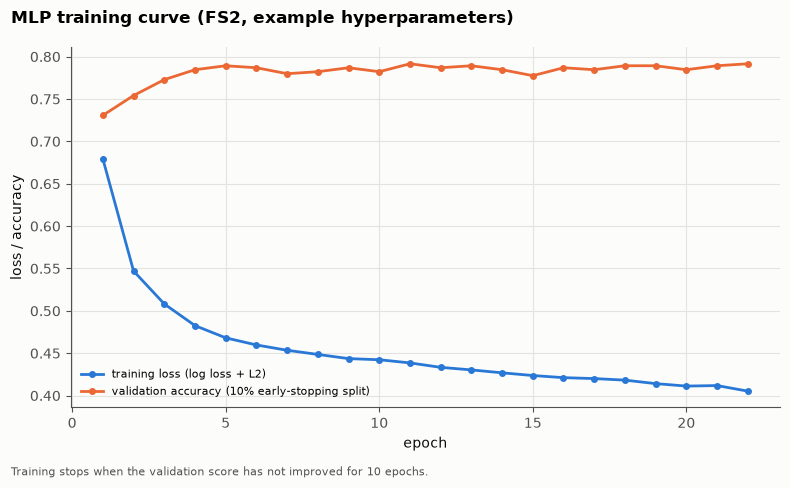

In [5]:
from sklearn.linear_model import LogisticRegression

arch_rows = []
for name, params in [
    ("logreg_l2", {"C": 1.0}),
    ("mlp", {"hidden_layer_sizes": "64-32", "alpha": 1e-4, "learning_rate_init": 1e-3}),
]:
    pipe = get_model(name).build({**params, "missing_strategy": "M2", "seed": nb.seed}, fs2)
    pipe.fit(x2, data.y)
    n_inputs = pipe.named_steps["prep"].transform(x2.iloc[:5]).shape[1]
    clf = pipe.named_steps["clf"]
    if isinstance(clf, LogisticRegression):
        layers, n_params, n_iter = [n_inputs, 1], clf.coef_.size + clf.intercept_.size, int(clf.n_iter_[0])
    else:
        mlp = clf
        layers = [n_inputs, *clf.hidden_layer_sizes, 1]
        n_params = sum(w.size for w in clf.coefs_) + sum(b.size for b in clf.intercepts_)
        n_iter = clf.n_iter_
    arch_rows.append(
        {
            "model": name,
            "layers (units)": " -> ".join(str(n) for n in layers),
            "trainable parameters": n_params,
            "iterations run": n_iter,
        }
    )
display(pd.DataFrame(arch_rows).set_index("model"))

epochs = np.arange(1, len(mlp.loss_curve_) + 1)
curves = {"training loss (log loss + L2)": pd.DataFrame({"epoch": epochs, "value": mlp.loss_curve_})}
if getattr(mlp, "validation_scores_", None) is not None:
    curves["validation accuracy (10% early-stopping split)"] = pd.DataFrame(
        {"epoch": epochs, "value": mlp.validation_scores_}
    )
show(
    figures.line_curves(
        curves,
        "epoch",
        "value",
        "MLP training curve (FS2, example hyperparameters)",
        "epoch",
        "loss / accuracy",
        note="Training stops when the validation score has not improved for 10 epochs.",
    )
)

## 3. Evaluation design

| Scheme | Design | Role |
|---|---|---|
| **S1** LOHO | Each hospital held out in turn; 20% of the rest is the calibration split; tuning by facility-grouped CV on the remaining 80% | **Primary**: the selection rule reads it |
| S2 | S1, then the held-out hospital's first 150 admissions refit the intercept | Transport with a local update |
| S3 | Internal nested CV (5 outer folds) | Only to size the internal-vs-LOHO gap |
| S4 | Train November-January, test February-March | Robustness over time |
| S5 | All hospitals, 80/20 fit/calibration | Produces the deployment artefact |

A woman's rows never straddle the fit, calibration and test sets (splits are grouped by mother).

**Metrics.** AUC (discrimination), calibration slope (1 is ideal; below 1 = predictions too extreme),
calibration-in-the-large (0 is ideal), Brier score, **log loss** (the tuning objective), net benefit, and, at a
0.5 threshold, accuracy, precision, recall, specificity and F1. Per-hospital metrics are summarised by their
mean and range across the four held-out hospitals.

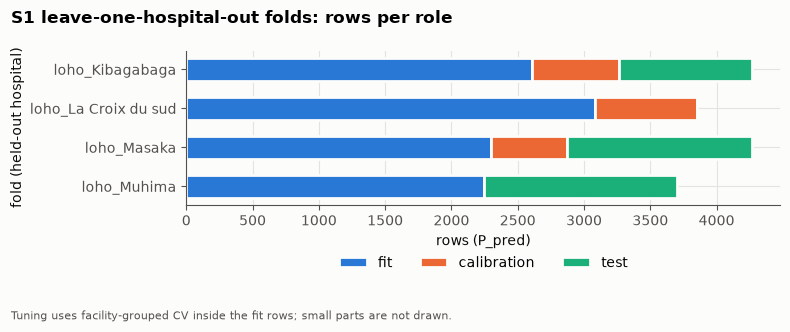

In [6]:
s1_folds = make_folds(data.meta, "S1", nb.seed)
fold_names = [f.name for f in s1_folds]
sizes = pd.DataFrame(
    {
        f.name: {
            "fit": len(f.fit_idx),
            "calibration": len(f.calib_idx),
            "excluded (shared mother)": len(f.excluded_idx),
            "test": len(f.test_idx),
        }
        for f in s1_folds
    }
).T
sizes = suppress_partition(sizes, list(sizes.columns))
show(
    figures.stacked_bars(
        sizes[["fit", "calibration", "test"]].T,
        "S1 leave-one-hospital-out folds: rows per role",
        "rows (P_pred)",
        "fold (held-out hospital)",
        note="Tuning uses facility-grouped CV inside the fit rows; small parts are not drawn.",
    )
)

## 4. Training

Each configuration (model, feature set, missing strategy, split, population, seed, trials) is one
`evaluate.run_experiment` call. For every fold the harness:

1. **tunes** hyperparameters with Optuna TPE (seeded), minimising inner-CV mean log loss (section 5);
2. **refits** the Pipeline on the fit rows with the best hyperparameters;
3. **calibrates**: none, Platt or isotonic, chosen by cross-validated Brier score within the calibration split;
4. **predicts** the held-out rows.

Everything is logged to MLflow (section 6). Training the full grid takes several hours, so on real data it
was run beforehand with `robson-ml run`; synthetic mode trains a small grid here.

In [7]:
if nb.mode == "synthetic":
    data_onset = build_model_data(classified, registry, raw_features, "P_pred_onset_coded")
    notebook.train_synthetic(nb, data, data_onset, registry)
elif nb.run_live:
    live_dir = Path(tempfile.mkdtemp(prefix="robson_live_"))
    demo = run_experiment(
        ExperimentConfig("logreg_l2", "FS0", "M1", "S1", "P_pred", 5, nb.seed, 200),
        data,
        notebook.run_context(nb, registry, live_dir=live_dir),
    )
    print(f"demonstration run {demo.config.name}: mean AUC {demo.summary['mean_auc']:.3f} "
          f"(tracked in a temporary store: {live_dir})")
else:
    print("results are read from the saved experiment runs (mlruns/)")

runs = load_runs(nb.tracking_uri)
s1 = runs[(runs["split"] == "S1") & (runs["population"] == "P_pred")]
best = tracking.best_per_model(runs)  # the best S1 configuration of every model
print(f"finished runs: {len(runs)}; S1 configurations: {len(s1)}; models: {len(best)}")

results are read from the saved experiment runs (mlruns/)


finished runs: 123; S1 configurations: 57; models: 11


## 5. Hyperparameter tuning

Each fold is tuned with **Optuna's TPE sampler** (seeded): every *trial* proposes hyperparameters, scores
them by the mean log loss over the inner facility-grouped folds, and the next proposals concentrate where
the loss was low. The baselines B2/B3 are tuned over a small `C` grid, and B0/B1 have nothing to tune.

| Model | Search space |
|---|---|
| `logreg_l2` | `C` 1e-4 to 1e2 (log) |
| `elasticnet` | `C` (log), `l1_ratio` 0-1 |
| `xgboost` | learning rate 0.01-0.3 (log), max depth 2-8, subsample 0.5-1, column subsample 0.5-1, `reg_lambda` 1e-3 to 10 (log); trees by early stopping |
| `random_forest` | max depth 3-16, min leaf 1-50 (log), max features 0.1-0.8 |
| `cart` | max depth 2-10, min leaf 10-200 (log), `ccp_alpha` 1e-5 to 1e-2 (log) |
| `svm_rbf` | `C` 1e-2 to 1e2, `gamma` 1e-4 to 1 (both log) |
| `mlp` | hidden layers {32, 64, 64-32, 128-64}, `alpha` 1e-5 to 1e-1, learning rate 1e-4 to 1e-2 (log) |

**5.1 Tuning curves.** The trial history is not stored in MLflow, so the cell below **re-runs the tuning of
the first held-out hospital** for the best configuration of each main model family, with the run's own
settings and seed. It then checks that the winning hyperparameters match those MLflow logged for that fold.

**Tuning re-run on fold `loho_Kibagabaga`**

,configuration,trials,best inner-CV log loss,same as logged in MLflow,seconds
model,,,,,
logreg_l2,"FS2, M2",50,0.5198,True,205
xgboost,"FS2, M2",50,0.4903,True,237
random_forest,"FS2, M2",25,0.5004,True,267
mlp,"FS4, M2",50,0.5149,True,289


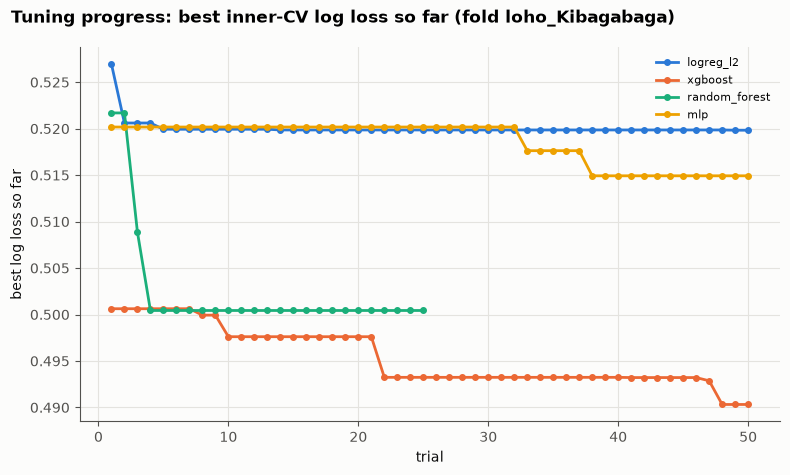

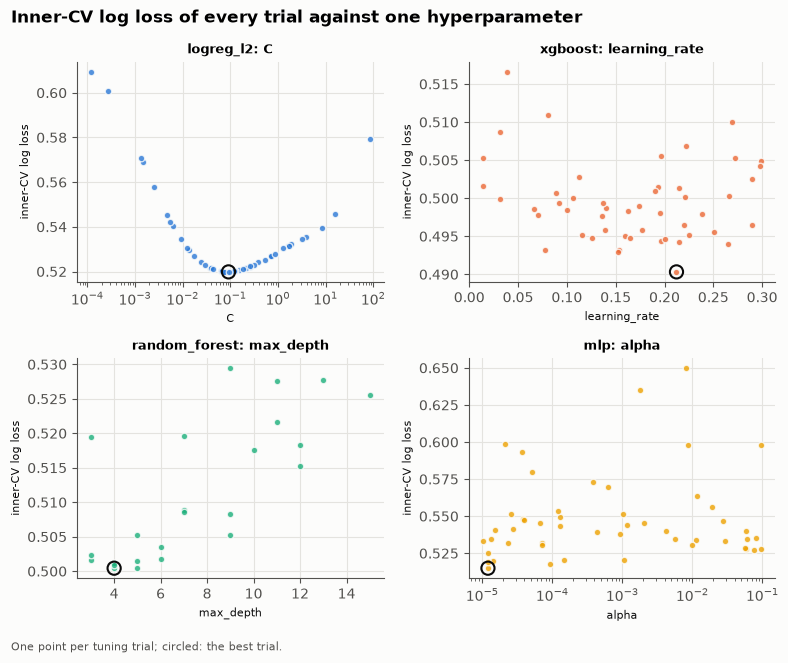

In [8]:
TUNING_DEMO = {  # model: the hyperparameter to plot the loss against
    "logreg_l2": "C",
    "xgboost": "learning_rate",
    "random_forest": "max_depth",
    "mlp": "alpha",
}
fold = s1_folds[0]
histories, checks = {}, []
for model, param in TUNING_DEMO.items():
    rows = best[best["model"] == model]
    if rows.empty:
        continue
    run = rows.iloc[0]
    started = time.time()
    study = fold_tuning_study(data, experiment_config(run), fold)
    histories[model] = tracking.trial_history(study)
    logged = run_fold_params(nb.tracking_uri, run["run_id"]).get(metric_key(fold.name), {})
    checks.append(
        {
            "model": model,
            "configuration": f"{run['feature_set']}, {run['missing_strategy']}",
            "trials": len(histories[model]),
            "best inner-CV log loss": study.best_value,
            "same as logged in MLflow": tracking.same_params(study.best_trial.user_attrs["params"], logged),
            "seconds": round(time.time() - started),
        }
    )
display(Markdown(f"**Tuning re-run on fold `{fold.name}`**"))
display(pd.DataFrame(checks).set_index("model").round(4))
show(
    figures.line_curves(
        {m: h for m, h in histories.items()},
        "trial",
        "best_log_loss",
        f"Tuning progress: best inner-CV log loss so far (fold {fold.name})",
        "trial",
        "best log loss so far",
    )
)
show(
    figures.tuning_panels(
        {f"{m}: {TUNING_DEMO[m]}": (h, TUNING_DEMO[m]) for m, h in histories.items()},
        "Inner-CV log loss of every trial against one hyperparameter",
    )
)

**5.2 Tuned hyperparameters on every held-out hospital.** Read from MLflow for the best configuration of
each tuned model. Stable values across folds mean the tuning is not chasing noise in one hospital.

In [9]:
# Baselines B2/B3 pick C from a tiny grid (the same value on every hospital): left out.
tuned = [
    tracking.fold_params_table(run_fold_params(nb.tracking_uri, run["run_id"]), run["model"])
    for _, run in best[~best["model"].isin(BASELINE_MODELS)].iterrows()
]
pd.concat([t for t in tuned if not t.empty]).rename_axis(columns="held-out hospital")

held-out hospital                 Kibagabaga La Croix du sud   Masaka   Muhima
model          hyperparameter                                                 
mlp            alpha                     0.0          0.0008   0.0592   0.0988
               hidden_layer_sizes     128-64              64    64-32       32
               learning_rate_init     0.0013          0.0006   0.0004    0.007
random_forest  max_depth                 4.0             4.0      3.0      5.0
               max_features           0.3665          0.3665    0.432    0.743
               min_samples_leaf          1.0             1.0      5.0     16.0
logreg_l2      C                      0.0916          0.1682   0.1074   0.2053
elasticnet     C                      0.2093          0.3932   0.1472   0.1742
               l1_ratio               0.5842            0.95   0.5312   0.6346
xgboost        colsample_bytree       0.6801          0.6074   0.7584   0.6532
               learning_rate          0.2123          0.0996     0.27   0.2919
               max_depth                 2.0             2.0      2.0      2.0
               n_estimators             27.0            80.0     13.0     14.0
               reg_lambda             1.7807          0.0796   0.0049   0.1574
               subsample              0.9166          0.9643   0.8605   0.5713
ft_transformer d_token                  32.0            32.0     32.0     32.0
               dropout                0.2091          0.2091   0.0008   0.0008
               lr                     0.0034          0.0034   0.0043   0.0043
               n_blocks                  1.0             1.0      2.0      2.0
               weight_decay              0.0             0.0      0.0      0.0
svm_rbf        C                     83.8469         15.3748  83.8469  83.2292
               gamma                  0.0002          0.0021   0.0002   0.0014
cart           ccp_alpha              0.0001          0.0003   0.0001   0.0056
               max_depth                 2.0             3.0      2.0      6.0
               min_samples_leaf         13.0            21.0     13.0     29.0

## 6. Experiment tracking (MLflow)

Every run is logged to MLflow in `mlruns/` with its parameters (model, feature set, strategy, split, tuned
hyperparameters per fold, calibration choice), its metrics (per fold, mean, range and pooled: AUC,
calibration, Brier, log loss, accuracy, precision, recall, specificity, F1) and aggregate plots (ROC,
calibration, decision curve). To browse and compare runs interactively:

```bash
uv run mlflow ui --backend-store-uri mlruns    # then open http://127.0.0.1:5000
```

The charts below track the runs from here: how many were run, every S1 configuration's AUC in run order,
and the best AUC and log loss of each model on each feature set.

runs per split,S1,S2,S3,S4
population,,,,
P_pred,57,11,13,9
P_pred_complete,25,0,0,0
P_pred_onset_coded,8,0,0,0


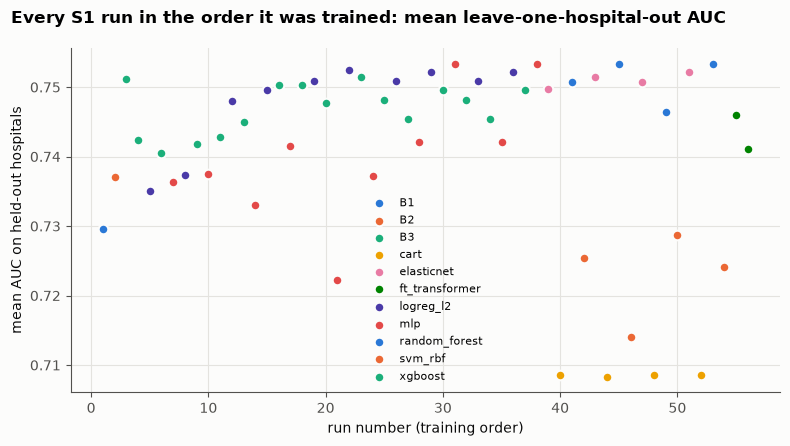

In [10]:
display(
    runs.pivot_table(index="population", columns="split", values="run_id", aggfunc="count", fill_value=0)
    .rename_axis(columns="runs per split")
)
history = s1[s1["model"] != "B0"].sort_values("start_time").reset_index(drop=True)
history["run number"] = np.arange(1, len(history) + 1)
show(
    figures.scatter_groups(
        history,
        "run number",
        "mean_auc",
        "model",
        "Every S1 run in the order it was trained: mean leave-one-hospital-out AUC",
        "run number (training order)",
        "mean AUC on held-out hospitals",
    )
)

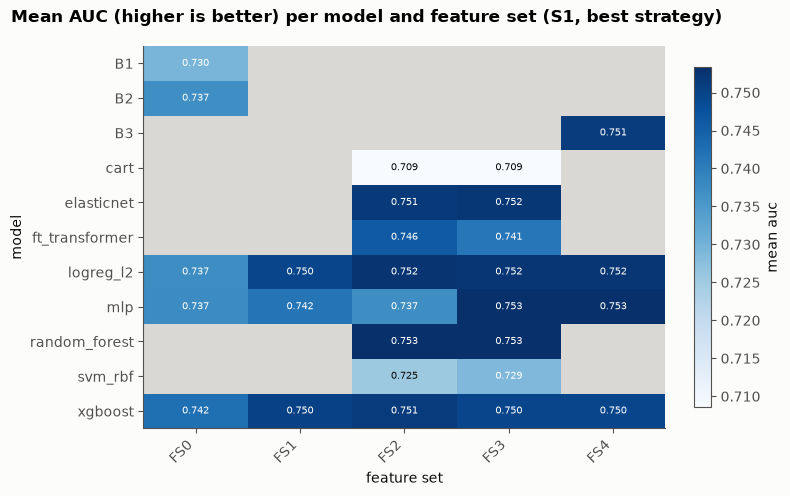

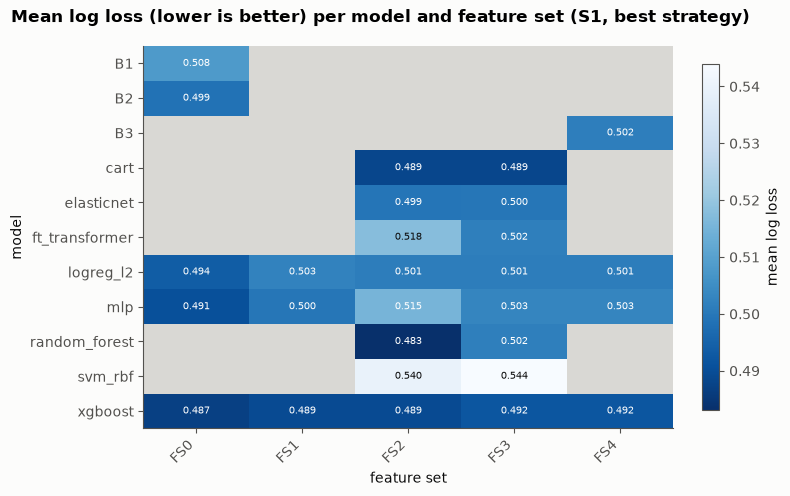

In [11]:
grid = s1[s1["model"] != "B0"]
for metric, best_of, title, cmap in (
    ("mean_auc", "max", "Mean AUC (higher is better)", figures.SEQUENTIAL),
    ("mean_log_loss", "min", "Mean log loss (lower is better)", "Blues_r"),
):
    show(
        figures.heatmap(
            grid.pivot_table(index="model", columns="feature_set", values=metric, aggfunc=best_of),
            f"{title} per model and feature set (S1, best strategy)",
            "feature set",
            "model",
            metric.replace("_", " "),
            cmap=cmap,
            fmt="{:.3f}",
        )
    )

## 7. Performance metrics per model

The best configuration of every model (highest mean S1 AUC), scored on its **pooled out-of-fold
predictions**: every prediction is for a hospital the model did not see in training. Accuracy, precision,
recall, specificity and F1 cut the probability at **0.5**; AUC, log loss and Brier judge the probability
itself. Best value per column in bold.

In [12]:
performance = tracking.performance_table(best, nb.load_oof)
higher = ["mean AUC (per fold)", "pooled AUC", *tracking.THRESHOLD_METRICS]
lower = ["log loss", "Brier"]
(
    performance.style.format(precision=3)
    .highlight_max(subset=higher, props="font-weight: bold")
    .highlight_min(subset=lower, props="font-weight: bold")
)

,configuration,mean AUC (per fold),pooled AUC,accuracy,precision,recall,specificity,F1,log loss,Brier
model,,,,,,,,,,
mlp,"FS4, M2",0.753,0.733,0.783,0.687,0.379,0.935,0.488,0.507,0.163
random_forest,"FS2, M2",0.753,0.739,0.808,0.865,0.352,0.979,0.500,0.484,0.153
logreg_l2,"FS2, M2",0.752,0.734,0.789,0.713,0.378,0.943,0.494,0.502,0.161
elasticnet,"FS3, M2",0.752,0.736,0.791,0.726,0.376,0.947,0.495,0.500,0.160
xgboost,"FS2, M2",0.751,0.741,0.804,0.823,0.362,0.971,0.503,0.491,0.156
B3,"FS4, M1",0.751,0.733,0.789,0.711,0.383,0.942,0.498,0.502,0.161
ft_transformer,"FS2, M2",0.746,0.728,0.796,0.784,0.347,0.964,0.481,0.527,0.162
B2,"FS0, M1",0.737,0.727,0.808,0.860,0.355,0.978,0.502,0.498,0.155
B1,"FS0, M0",0.730,0.715,0.788,0.732,0.354,0.951,0.477,0.506,0.163


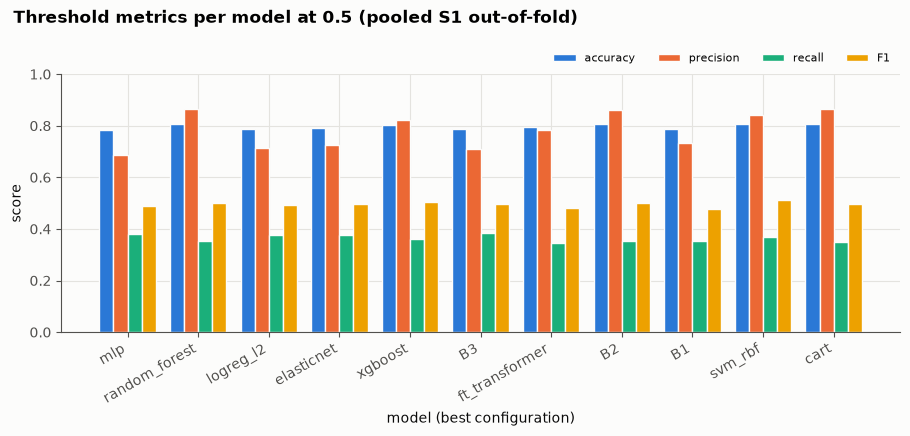

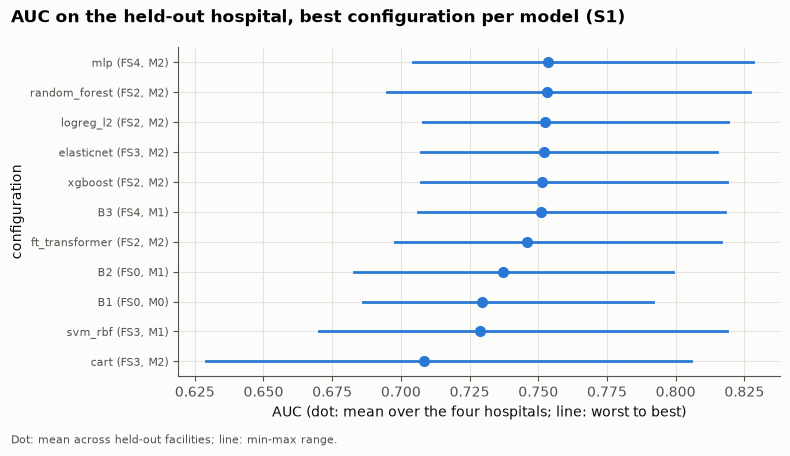

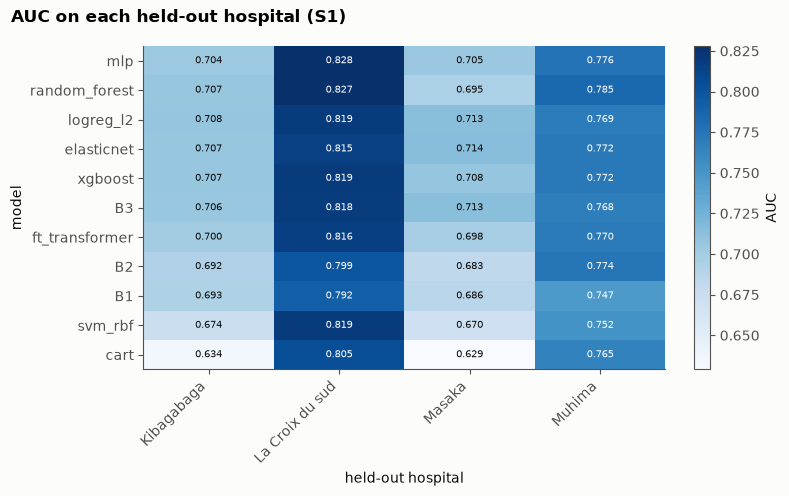

In [13]:
show(
    figures.grouped_bars(
        performance[["accuracy", "precision", "recall", "F1"]],
        "Threshold metrics per model at 0.5 (pooled S1 out-of-fold)",
        "model (best configuration)",
        "score",
        ylim=(0, 1),
    )
)
show(
    figures.range_plot(
        best.assign(label=best["model"] + " (" + best["feature_set"] + ", " + best["missing_strategy"] + ")"),
        "label",
        "mean_auc",
        "min_auc",
        "max_auc",
        "AUC on the held-out hospital, best configuration per model (S1)",
        "AUC (dot: mean over the four hospitals; line: worst to best)",
    )
)
per_hospital = fold_metrics(best, fold_names, "auc")
per_hospital.index = best["model"].tolist()
per_hospital.columns = [c.removeprefix("loho_") for c in per_hospital.columns]
show(
    figures.heatmap(
        per_hospital.round(3),
        "AUC on each held-out hospital (S1)",
        "held-out hospital",
        "model",
        "AUC",
        fmt="{:.3f}",
    )
)

## 8. Confusion matrix per model

The same pooled out-of-fold predictions cut at 0.5. Each cell shows the count and its share of the observed
class: the CS row's right cell is the recall, the vaginal row's left cell the specificity.

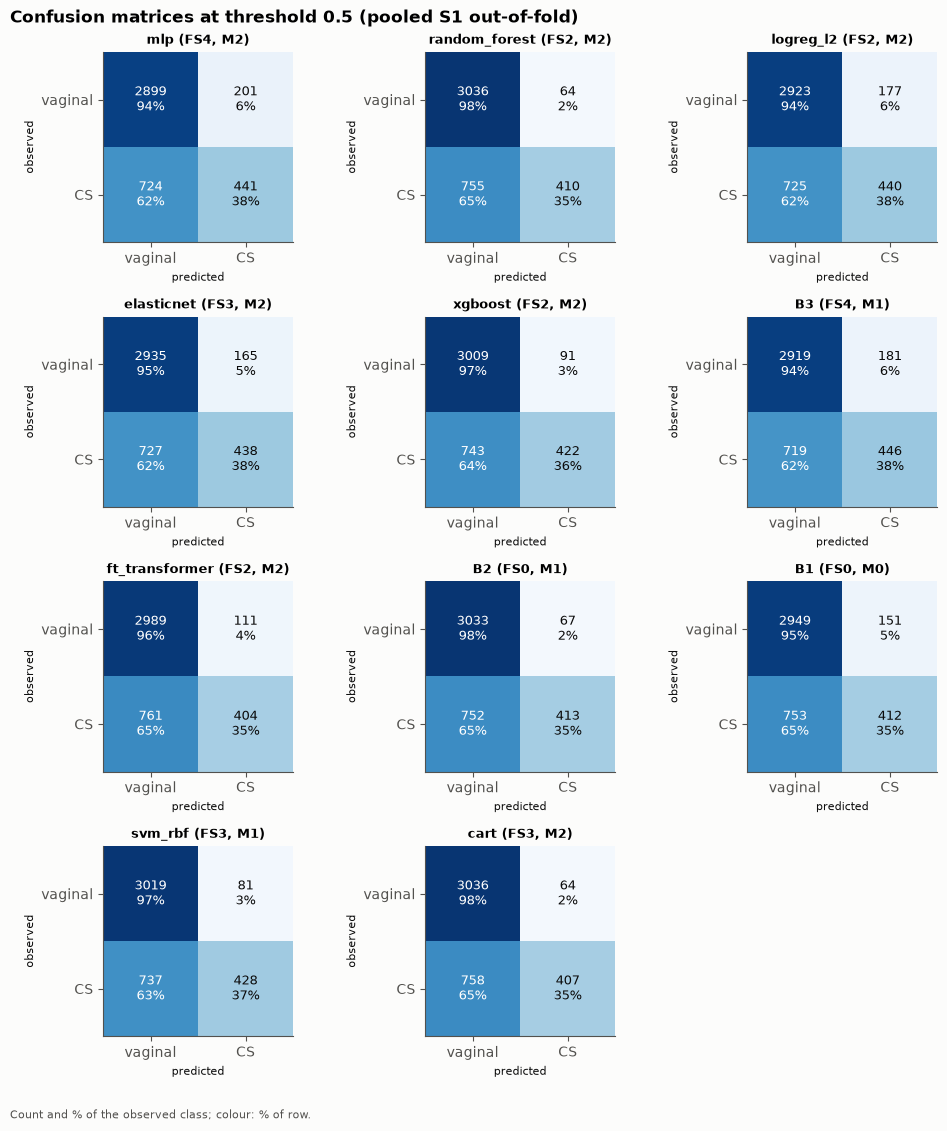

In [14]:
matrices = {}
for _, run in best.iterrows():
    oof = nb.load_oof(run["run_id"])
    if oof is not None:
        matrices[f"{run['model']} ({run['feature_set']}, {run['missing_strategy']})"] = (
            tracking.confusion_counts(oof["y"], oof["p"])
        )
show(figures.confusion_grid(matrices, "Confusion matrices at threshold 0.5 (pooled S1 out-of-fold)"))

## 9. Calibration and clinical utility

Calibration (does a predicted 30% come true about 30% of the time?) and the decision curve (net benefit of
anticipating CS at each threshold, against flagging everyone or no one), for the three best models and B1.
The decision curve concerns *anticipating theatre demand*, not deciding any woman's care.

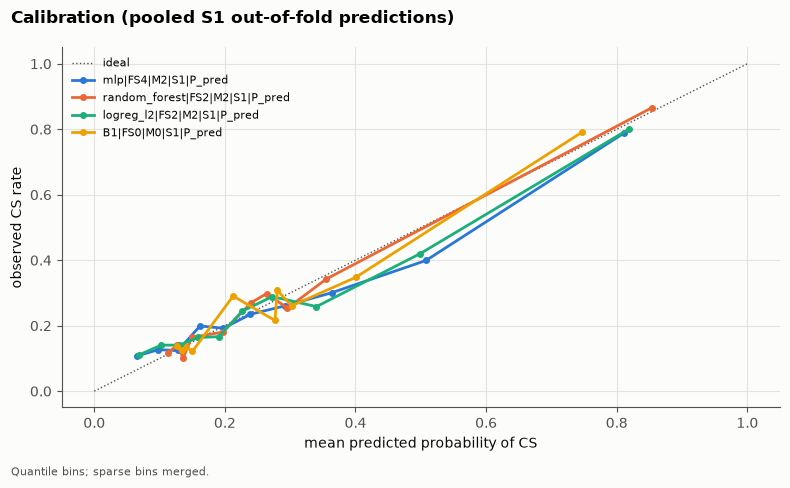

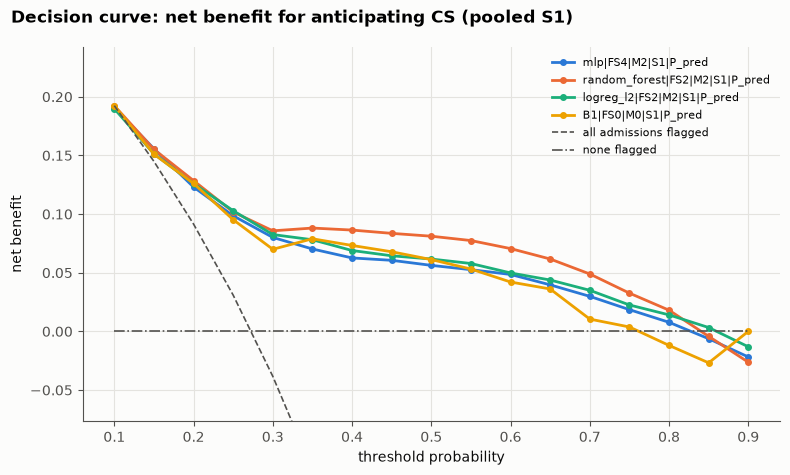

In [15]:
shown = pd.concat([best[~best["model"].isin(["B1", "B2", "B3"])].head(3), best[best["model"] == "B1"]])
calibration, decision = {}, {}
for _, run in shown.iterrows():
    oof = nb.load_oof(run["run_id"])
    if oof is not None:
        calibration[run["config"]] = calibration_bins(oof["y"], oof["p"])
        decision[run["config"]] = net_benefit(oof["y"], oof["p"])
show(
    figures.line_curves(
        calibration,
        "mean_p",
        "observed",
        "Calibration (pooled S1 out-of-fold predictions)",
        "mean predicted probability of CS",
        "observed CS rate",
        diagonal=True,
        note="Quantile bins; sparse bins merged.",
    )
)
reference = next(iter(decision.values()))
show(
    figures.line_curves(
        decision,
        "threshold",
        "model",
        "Decision curve: net benefit for anticipating CS (pooled S1)",
        "threshold probability",
        "net benefit",
        references={
            "all admissions flagged": reference[["threshold", "treat_all"]].rename(columns={"treat_all": "model"}),
            "none flagged": reference[["threshold", "treat_none"]].rename(columns={"treat_none": "model"}),
        },
        ylim=(min(min(float(d["model"].min()) for d in decision.values()), 0.0) - 0.05,
              max(float(reference["treat_all"].max()), 0.0) + 0.05),
    )
)

## 10. Model selection

`configs/selection_rule.yaml` was committed **before any model was run on real data**, and the harness
refuses a real-data run if it changes. `select.select_configuration` applies it mechanically:

1. **Eligible:** S1, `P_pred`, not a baseline, mean calibration slope within the rule's interval.
2. **Rank** by mean leave-one-hospital-out AUC.
3. **Tie-break:** within `within_auc` of the best, take the simplest model (lowest complexity rank).
4. **Baseline check** against B1.

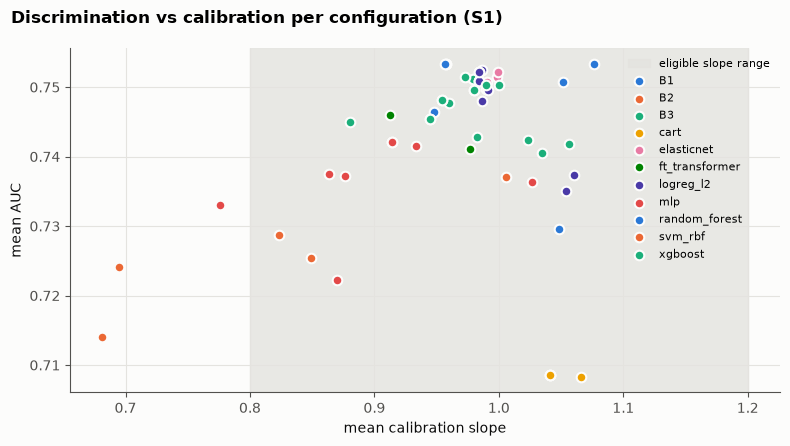

- 50 of 53 candidate configurations are eligible (mean LOHO calibration slope in [0.8, 1.2]); best mean LOHO AUC 0.753; 30 within 0.01 of it; lowest complexity rank among them: 1.
- Baseline check passed: mean LOHO AUC 0.7524 > B1 0.7295.

SELECTED: logreg_l2|FS2|M2|S1|P_pred


**Tie band: 30 configurations within `within_auc` of the best; the 10 shown are the best by AUC**

,complexity_rank,mean_auc,min_auc,max_auc,mean_calibration_slope
config,,,,,
mlp|FS3|M2|S1|P_pred,7,0.753,0.704,0.828,0.957
mlp|FS4|M2|S1|P_pred,7,0.753,0.704,0.828,0.957
random_forest|FS2|M2|S1|P_pred,4,0.753,0.695,0.827,1.076
random_forest|FS3|M2|S1|P_pred,4,0.753,0.702,0.822,0.957
logreg_l2|FS2|M2|S1|P_pred,1,0.752,0.708,0.819,0.987
logreg_l2|FS4|M2|S1|P_pred,1,0.752,0.707,0.819,0.984
logreg_l2|FS3|M2|S1|P_pred,1,0.752,0.707,0.819,0.984
elasticnet|FS3|M2|S1|P_pred,2,0.752,0.707,0.815,0.999
elasticnet|FS2|M2|S1|P_pred,2,0.751,0.708,0.815,0.999


In [16]:
rule = load_selection_rule(nb.selection_rule_path)
show(
    figures.scatter_groups(
        s1[s1["model"] != "B0"],
        "mean_calibration_slope",
        "mean_auc",
        "model",
        "Discrimination vs calibration per configuration (S1)",
        "mean calibration slope",
        "mean AUC",
        xband=rule.slope_range,
        band_label="eligible slope range",
    )
)
selection = select_configuration(runs, rule)
for line in selection.notes:
    print(f"- {line}")
if selection.selected is not None:
    print(f"\nSELECTED: {selection.selected['config']}")
    # The 10 best of the tie band, plus the selected configuration if it ranks lower.
    band = selection.tie_band.sort_values("mean_auc", ascending=False)
    top = band.head(10)
    if selection.selected["config"] not in set(top["config"]):
        top = pd.concat([top, band[band["config"] == selection.selected["config"]]])
    display(Markdown(f"**Tie band: {len(band)} configurations within `within_auc` of the best; "
                     f"the {len(top)} shown are the best by AUC**"))
    display(
        top[["config", "complexity_rank", "mean_auc", "min_auc", "max_auc", "mean_calibration_slope"]]
        .set_index("config")
        .round(3)
    )

**Next:** [`03_model_evaluation.ipynb`](03_model_evaluation.ipynb) interprets the selected model and tests its
robustness (later time period, internal vs external validation, missing data, deployment).